In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from sam.dataset import generate_dual_task_batch, generate_dual_task_batch_parallel

from configurations import load_data, set_font_sizes, create_fig, apply_general_styles, save_fig, make_params_dict
from configurations.plot_config import FONTSIZES

apply_general_styles()

# Test induction head

In [77]:
# Load picke

data = load_data('temp',experiment_name='tmp')

for key, value in data.items():
    print(f"{key}: {value.shape}")


# data['input']

File temp.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
S1: (10, 15, 15)
A1: (10, 15, 15)
Y1: (10, 15, 1000)
S2: (10, 15, 15)
A2: (10, 15, 15)
Y2: (10, 15, 1000)
X2: (10, 15, 1000)
Y3: (10, 15, 1000)
X3: (10, 15, 1000)
logits: (10, 15, 20)
logits_X2: (10, 15, 20)
logits_Y3: (10, 15, 20)
input: (10, 15)


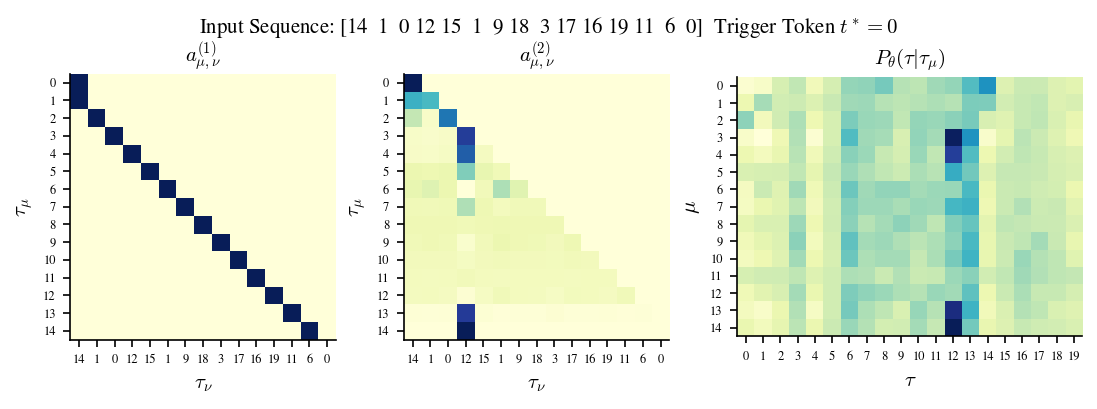

Figure saved on /u/c/cerazova/SAM/plots/2026-03 as dual_task.png


In [104]:
# Settings
i_batch = 6
cmap = 'YlGnBu'

set_font_sizes(conf='tight')

# Plots
fig , axes = create_fig(ncols=3,size='double',h=0.35,w=1,w_ratios=[1,1,1.3],
                        sharex=False, sharey=False)

for i , ax in enumerate(axes[:2]):
    A = data[f'A{i+1}'][i_batch]  # shape (seq_len, seq_len)
    ax.set_title(rf'$a^{{({i+1})}}_{{\mu,\nu}}$')
    ax.set_xlabel(r'$\tau_\nu$')
    ax.set_ylabel(r'$\tau_\mu$')
    input = data['input'][i_batch]
    im = ax.imshow(A, cmap=cmap)#,vmax=0.3)
    # plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(A.shape[0]),input)
    ax.set_yticks(np.arange(A.shape[0]))

ax = axes[2]
log = 0.5*data['logits'][i_batch] # shape (seq_len, vocab_size)
P = np.exp(log) / np.exp(log).sum(axis=-1, keepdims=True)  # shape (seq_len, vocab_size)
im = ax.imshow(P, cmap=cmap)#,vmax=0.3)
# plt.colorbar(im, ax=ax)
ax.set_ylabel(r'$\mu$')
ax.set_xlabel(r'$\tau$')
ax.set_title(r'$P_\theta(\tau|\tau_\mu)$')
ax.set_xticks(np.arange(log.shape[1]))
ax.set_yticks(np.arange(log.shape[0]))

fig.suptitle(f'Input Sequence: {data["input"][i_batch]} '+r' Trigger Token $t^*=0$')
plt.show()

save_fig(fig,'dual_task',date=True)


# Check loss

In [43]:
d = 1024
alpha = 2

data = load_data('dual_task_check',experiment_name='tmp',params={'d_model':d,'alpha':alpha})

for key in data.keys():
    data[key] = np.array(data[key])
    print(f"{key}: {data[key].shape}")

File dual_task_check_alpha2_d_model1024.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
V_values: (10,)
loss: (10,)
accuracy: (10,)
entropy_P_u: (10,)
max_entropy: (10,)


Text(0.35, 0.15, '$\\sqrt{d}$')

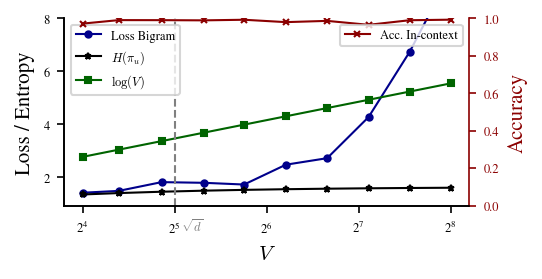

In [44]:
# Settings

set_font_sizes(conf='tight')


# Plot
fig , axes = create_fig()

ax = axes 
ax.spines['right'].set_visible(True)
ax.spines['right'].set_color('darkred')
ax.set_xlabel(r'$V$')
ax.set_ylabel('Loss / Entropy')
ax.set_xscale('log',base=2)
ax.plot(data['V_values'],data['loss'],label='Loss Bigram',color='darkblue',marker='o',markersize=3,lw=1)
ax.plot(data['V_values'],data['entropy_P_u'],label=r'$H(\pi_u)$',color='black',marker='*',markersize=3,lw=1)
ax.plot(data['V_values'],data['max_entropy'],label=r'$\log(V)$',color='darkgreen',marker='s',markersize=3,lw=1)
ax.legend(loc=2)
ax.axvline(math.sqrt(d),color='gray',ls='--',label=r'$\sqrt{d}$',lw=1)
ax.set_ylim(top=8)

ax_twin = ax.twinx()
ax_twin.set_ylabel(r'Accuracy',color='darkred')
ax_twin.plot(data['V_values'],data['accuracy'],color='darkred',label='Acc. In-context',marker='x',markersize=3,lw=1)
ax_twin.legend(loc=1)
ax_twin.set_ylim(0,1)
# color the axis red
ax_twin.tick_params(axis='y', colors='darkred')

fig.text(0.35,0.15,r'$\sqrt{d}$',color='gray',ha='center',size=FONTSIZES['xs'])

# save_fig(fig,'dual_task_check',params={'d':d,'alpha':alpha,'L':256,'K':10},date=True)

In [14]:
math.sqrt(d)

45.254833995939045

# Bi vs ind loss

In [53]:
d = 2048
alpha = 2
vocab_size = 32

data = load_data('dual_task_compare_loss',experiment_name='tmp',params={'d_model':d,'alpha':alpha})

for key in data.keys():
    data[key] = np.array(data[key])
    print(f"{key}: {data[key].shape}")

File dual_task_compare_loss_alpha2_d_model2048.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
K_values: (8,)
loss_bi: (8,)
loss_ind: (8,)
loss_tot: (8,)
entropy_P_u: ()
max_entropy: ()


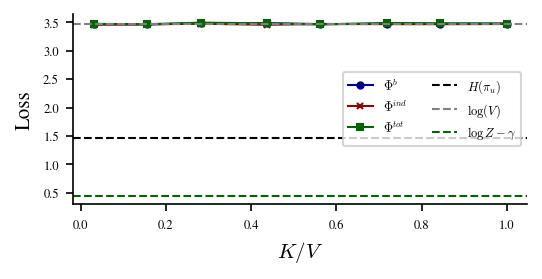

In [54]:
# Settings
set_font_sizes(conf='tight')

# Plot
fig , axes = create_fig()

ax = axes
Ks = data['K_values']/vocab_size
loss_bi = data['loss_bi']
loss_ind = data['loss_ind']
loss_tot = data['loss_tot']
ax.plot(Ks, loss_bi, label=r'$\Phi^{b}$', color='darkblue', marker='o', markersize=3, lw=1)
ax.plot(Ks, loss_ind, label='$\Phi^{ind}$', color='darkred', marker='x', markersize=3, lw=1)
ax.plot(Ks, loss_tot, label='$\Phi^{tot}$', color='darkgreen', marker='s', markersize=3, lw=1)
ax.set_xlabel(r'$K/V$')
ax.set_ylabel('Loss')
# ax.legend()

ax.axhline(data['entropy_P_u'], color='black', ls='--', label=r'$H(\pi_u)$', lw=1)
ax.axhline(data['max_entropy'], color='gray', ls='--', label=r'$\log(V)$', lw=1)
gamma = 4.0
Z = math.exp(gamma) + vocab_size - 1

ax.axhline(math.log(Z)-gamma, color='darkgreen', ls='--', label=r'$\log Z-\gamma$', lw=1)
ax.legend(ncols=2)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_title(f'Loss vs K for d={d}, alpha={alpha}')


# save_fig(fig,'dual_task_compare_loss',params={'d':d,'alpha':alpha,'L':256,'V':vocab_size},date=True)

In [34]:
np.logspace(-0.1,np.log10(vocab_size),num=10,dtype=int)

array([ 0,  1,  1,  2,  4,  7, 11, 17, 27, 42])

In [23]:
gamma = 4.0
Z = math.exp(gamma) + vocab_size - 1
print(-gamma + math.log(Z))

0.5601534687523824


# Dirichlet prior

tensor(1.1755e-38) tensor(0.9488)


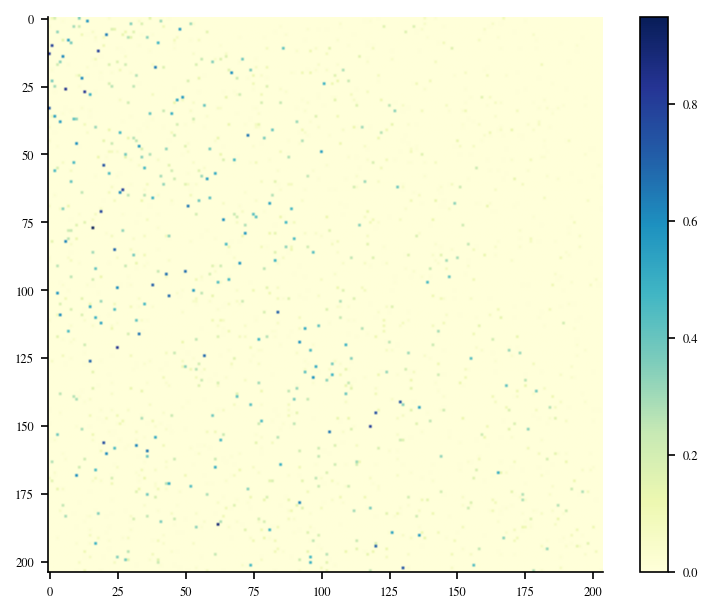

Entropy of P_u: 5.105623722076416
Max entropy: 5.318119993844216
Average KL divergence between bigram distribution and uniform distribution: 3.7968
KL divergence between unigram distribution and uniform distribution: 0.2125


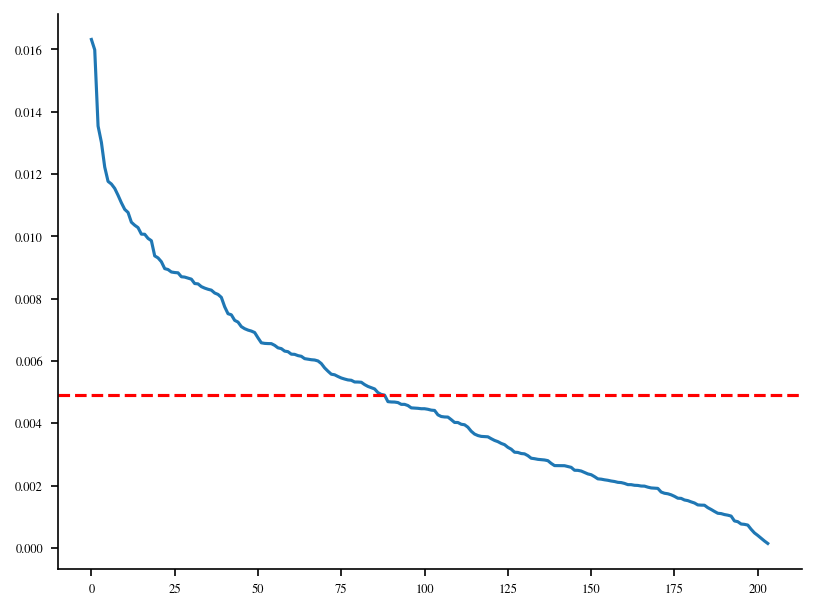

In [185]:
vocab_size = 204
beta = 0.01
config = {
    'vocab_size': vocab_size,
    'beta': beta,
}

# Sample a bigram distribution P_b[i,j]  = P(token j | token i) from a dirichlet prior with concentration parameter beta


concentration = torch.ones((vocab_size, vocab_size)) * config['beta']
P_b = torch.distributions.dirichlet.Dirichlet(concentration).sample()
print(P_b.min(), P_b.max())
# Compute stationary distribution as the eigenvector of P_b^T with eigenvalue 1
eigenvalues, eigenvectors = torch.linalg.eig(P_b.T)
P_u = eigenvectors[:, torch.isclose(eigenvalues.real, torch.tensor(1.0))].real.squeeze()
P_u /= P_u.sum()  # Normalize

# Sort by descending order of P_u
sorted_indices = torch.argsort(P_u, descending=True)
P_u = P_u[sorted_indices]
P_b = P_b[sorted_indices][:, sorted_indices]



plt.imshow(P_b, cmap='YlGnBu')
plt.colorbar()  
plt.show()
plt.plot(P_u)
plt.axhline(1/vocab_size, color='red', ls='--', label=r'Uniform $\frac{1}{V}$')

# Entropy of the stationary distribution
entropy_P_u = -torch.sum(P_u * torch.log(P_u + 1e-10))  # Add small constant for numerical stability
print(f"Entropy of P_u: {entropy_P_u.item()}")
print(f'Max entropy: {math.log(vocab_size)}')
# plt.yscale('log')
# plt.xscale('log')

# Average dkl between bigram distribution and uniform 1/V
avg_dkl_uniform = (P_b * (torch.log(P_b + 1e-10) - math.log(1.0/config['vocab_size']))).sum(dim=-1).mean().item()
print(f"Average KL divergence between bigram distribution and uniform distribution: {avg_dkl_uniform:.4f}")

# dkl between unigram and uniform 1/V
dkl_unigram_uniform = (P_u * (torch.log(P_u + 1e-10) - math.log(1.0/config['vocab_size']))).sum().item()
print(f"KL divergence between unigram distribution and uniform distribution: {dkl_unigram_uniform:.4f}")


# New tests

In [2]:

def optimal_pop_losses(test_batch,P_b,p0=0.99):
    vocab_size = P_b.shape[-1]
    device = P_b.device
    input = test_batch['sequence'][:,1:-1].to(device) # shape (batch_size, seq_len-2)
    output = test_batch['sequence'][:,2:].to(device) # shape (batch_size, seq_len-2)
    is_trigg = test_batch['is_trigg'][:,1:].to(device) # shape (batch_size, seq_len-2)
    seq_len = input.shape[1]+2

    trigg_per_seq = is_trigg.sum(dim=-1).float().mean().item()/(seq_len-2)

    H_cond = -torch.sum(P_b * torch.log(P_b + 1e-10), dim=-1)  # shape (seq_len,)

    # Case 1: As if the model makes prediction with the dual 'teacher' model (up to p0 mass to avoid log(0) issues)
    input_eval = input[is_trigg==0] # shape (num_non_trigg_tokens,)
    loss = H_cond[input_eval]  # shape (num_non_trigg_tokens,)
    loss = loss.mean().item()
    pop_loss_1 = trigg_per_seq*(-np.log(p0)) + (1-trigg_per_seq)*loss

    # Case 2: As if the model makes prediction with induction head only, agnostic about frequencies
    pop_loss_2 = trigg_per_seq*(-np.log(p0)) + (1-trigg_per_seq)*np.log(vocab_size)

    # Case 3: As if the model makes predicitons with bigram statistics only
    loss_no_trig = H_cond[input]  # shape (batch_size, seq_len-2)

    # For loss2 evaluate the condition probability for each input,output pair 
    loss_trig = -torch.log(P_b[input,output]+1e-10)  # shape (batch_size, seq_len-2)

    # Where input is a trigger set loss = loss_trig, else loss = loss_no_trig
    loss = loss_no_trig.clone()
    loss[is_trigg==1] = loss_trig[is_trigg==1]
    pop_loss_3 = loss.mean().item()

    return pop_loss_1, pop_loss_2, pop_loss_3, trigg_per_seq

    


In [3]:
# Fix parameters
experiment_name = 'dual_task_new'
vocab_size = 64 # Vocabulary size
seq_len = 256  # Sequence length
d_model = 128 # Model dimension
batch_size = 64 # Batch size
opt = 'adam' # Optimizer
test_size = 200 # Number of samples in the test set

# Variable parameters
# K = 25 # Number of trigger tokens
lr = 0.005 # Learning rate
b_type = 'dirichlet' # P_b distribution type: dirichlet or spiked
u_type = 'dirichlet' # P_u distribution type: dirichlet or zipf (only used if b_type is spiked)
alpha = 0.1 # Dirichlet concentration parameter or exponent for the Zipf's law
beta = 0.9 # Beta parameter for spiked bigram distribution (only used if b_type is spiked)

fix_trig = True # Whether to fix the trigger tokens across all experiments.
trig_type = 'freq' # Whether the trigger tokens should be the most frequent (True) or least frequent (False) tokens according to P_u. Only used if fix_trig is True.
K = 2

config = {
    'vocab_size': vocab_size,
    'seq_len': seq_len,
    'd_model': d_model,
    'batch_size': batch_size,
    'opt': opt,
    'test_size': test_size,
    'K': K,
    'lr': lr,
    'b_type': b_type,
    'u_type': u_type,
    'alpha': alpha,
    'beta': beta,
    'fix_trig': fix_trig,
    'trig_type': trig_type,
    'dropout': 0.,
}

names_fix =  ['vocab_size','seq_len','d_model','batch_size','opt','test_size']
names_variable = ['K','lr','b_type','u_type','alpha','beta','fix_trig','trig_type']

# names_fix = ['vocab_size','seq_len','d_model']
# names_variable = ['lr','K','beta','fix_trig']

params = make_params_dict(names_fix,names_variable)


data = load_data('dual_task_train',experiment_name=f"{experiment_name}/measures",params=params)

for key in data.keys():
    print(f"{key}: {data[key].shape}")


# File saved with pickle.dump on /u/c/cerazova/SAM/data/dual_task_new/measures/batch_size64_d_model128_optadam_seq_len256_test_size200_vocab_size64 as dual_task_train_K2_alpha0.1_b_typedirichlet_beta0.9_fix_trigTrue_lr0.005_trig_typefreq_u_typedirichlet.pkl
# Completed: at Tue Mar 31 01:33:04 CEST 2026

File dual_task_train_K2_alpha0.1_b_typedirichlet_beta0.9_fix_trigTrue_lr0.005_trig_typefreq_u_typedirichlet.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/dual_task_new/measures/batch_size64_d_model128_optadam_seq_len256_test_size200_vocab_size64
model_steps: (10,)
step: (100,)
loss: (100,)
accuracy_top3: (100,)
accuracy: (100,)
kl_WF_b: (100,)
kl_b_WF: (100,)
kl_full_b: (100,)
kl_b_full: (100,)
kl_full_u: (100,)
loss_b_tot: (100,)
loss_b_filt: (100,)
loss_ind_tot: (100,)
loss_ind_filt: (100,)
entropy_Pb: ()
entropy_Pu: ()
kl_Pb_uniform: ()
kl_Pu_uniform: ()
max_entropy: ()
P_u: (64,)
P_b: (64, 64)
opt_loss_dual: ()
opt_loss_ind: ()
opt_loss_b: ()
trigg_per_seq: ()


In [4]:
from sam.dual_model import DualModel, initialize_dual_model
import time

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
P_b = torch.tensor(data['P_b']).to(device)  # shape (seq_len, seq_len)
P_u = torch.tensor(data['P_u']).to(device)  # shape (seq_len,)
P_t = P_u.clone()  # shape (seq_len,)
P_o = torch.ones_like(P_b,device=device) / (vocab_size-1)
P_o.fill_diagonal_(0)

P_b.sum(axis=-1)  # should be 1


# average KL between a uniform distribution and P_b
KL_uniform_P_b = (1/vocab_size * (math.log(1/vocab_size) - torch.log(P_b + 1e-10))).sum(dim=-1).mean().item()
print(f"Average KL divergence between uniform distribution and P_b: {KL_uniform_P_b:.4f}")

trigger_set = None
if fix_trig:
    if trig_type == 'freq':
        trigger_set = [k for k in range(K)]
    elif trig_type == 'rare':
        trigger_set = [vocab_size - 1 - k for k in range(K)] 
    elif trig_type == 'rand':
        trigger_set = torch.multinomial(P_t, num_samples=K, replacement=False).tolist()
    print(f"Using fixed {trig_type} trigger set")
    print(f"Length of trigger set: {len(trigger_set)}, Trigger set: {trigger_set}")
else:
    print(f"Using random trigger set at each sequence")

t0 = time.time()
test_batch = generate_dual_task_batch(test_size,seq_len,K,P_b,P_u,P_o,P_t,trigger_set=trigger_set)
t1 = time.time()
print(f"Time to generate test batch: {t1-t0:.2f} seconds")
phi1, phi2, phi3, trigg_per_seq = optimal_pop_losses(test_batch, P_b=P_b, p0=0.999)
print(f"Optimal population loss with teacher model: {phi1:.4f}")
print(f"Optimal population loss with induction head only: {phi2:.4f}")
print(f"Optimal population loss with bigram statistics only: {phi3:.4f}")
print(f"Average proportion of trigger tokens per sequence: {trigg_per_seq:.4f}")

t0 = time.time()
test_batch = generate_dual_task_batch_parallel(test_size,seq_len,K,P_b,P_u,P_o,P_t,trigger_set=trigger_set)
t1 = time.time()
print(f"Time to generate test batch in parallel: {t1-t0:.2f} seconds")
phi1, phi2, phi3, trigg_per_seq = optimal_pop_losses(test_batch, P_b=P_b, p0=0.999)
print(f"Optimal population loss with teacher model: {phi1:.4f}")
print(f"Optimal population loss with induction head only: {phi2:.4f}")
print(f"Optimal population loss with bigram statistics only: {phi3:.4f}")
print(f"Average proportion of trigger tokens per sequence: {trigg_per_seq:.4f}")


# model = DualModel(config).to(device)
# model , device = initialize_dual_model(model , P_b, trigger_set=trigger_set,init='random')
# test_batch = generate_dual_task_batch(batch_size,seq_len,K,P_b,P_u,P_o,P_t,trigger_set=trigger_set)


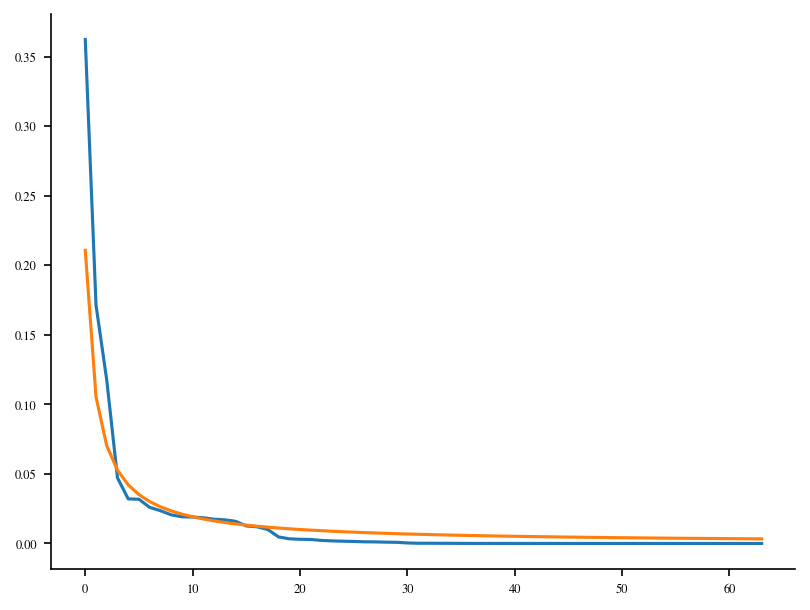

In [ ]:
P_u = torch.distributions.dirichlet.Dirichlet(torch.ones(vocab_size) * 0.1).sample()
P_u /= P_u.sum()
P_u = torch.sort(P_u, descending=True).values
plt.plot(P_u.cpu().numpy())
alpha = 1
P_zipf = torch.tensor([1/(k+1)**1 for k in range(vocab_size)],device=device)
P_zipf /= P_zipf.sum()
plt.plot(P_zipf.cpu().numpy())


std logits: 0.2250, mean logits: 0.0077
std logits_WF: 0.2250, mean logits_WF: -0.0042


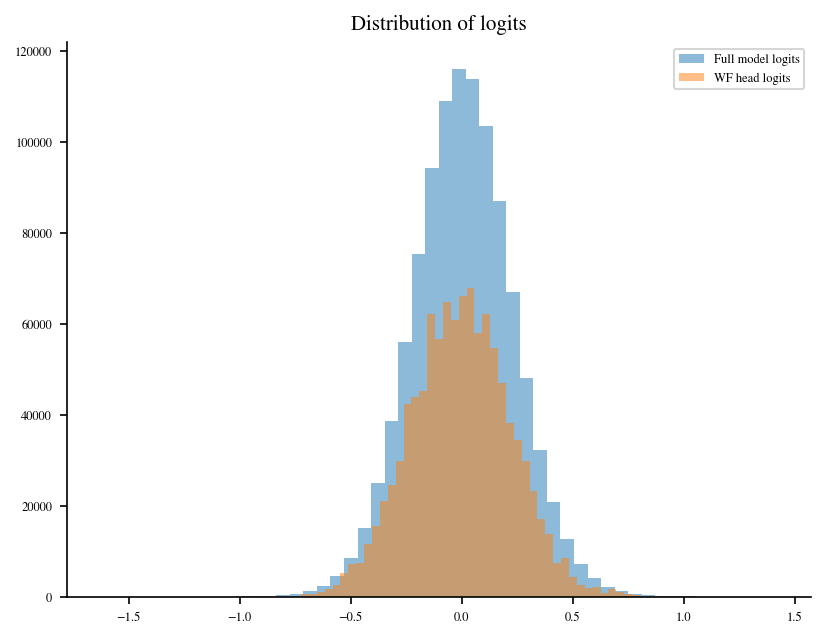

Average KL divergence between model and P_b: 10.4304
Average KL divergence between WF head and P_b: 10.3830


In [67]:
sequence = test_batch['sequence'].to(device) # shape (batch_size, seq_len + 1)
input = sequence[:, :-1] # shape (batch_size, seq_len)
target = sequence[:, 1:] 
mask = test_batch['mask'].to(device) # shape (batch_size, seq_len, seq_len)

logits = model(input, mask, attn=True, fc=True) # shape (batch_size, seq_len, vocab_size)

print(f'std logits: {logits.std().item():.4f}, mean logits: {logits.mean().item():.4f}')

X0 = model.E(input) # + model.P(model.positions.to(input.device)) # (batch_size, seq_len, d_model)
X3 = model.WF(X0) # (batch_size, seq_len, d_model)
logits_WF = model.U(X3) # (batch_size, seq_len, vocab_size)
std_logits_WF = logits_WF.std()
logits_WF = logits_WF * (logits.std() / std_logits_WF) # rescale logits to be on the same scale as full model logits
print(f'std logits_WF: {logits_WF.std().item():.4f}, mean logits_WF: {logits_WF.mean().item():.4f}')


plt.hist(logits.flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='Full model logits')
plt.hist(logits_WF.flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='WF head logits')
plt.legend()
plt.title('Distribution of logits')
plt.show()

# Compute average DKL(model||Pb)

target_prob = P_b[input]  # shape (batch_size, seq_len, vocab_size)
prob_model = torch.softmax(logits, dim=-1)  # shape (batch_size, seq_len, vocab_size)
prob_WF = torch.softmax(logits_WF, dim=-1)

kl1 = (prob_model * (torch.log(prob_model + 1e-10) - torch.log(target_prob + 1e-10))).sum(dim=-1).mean().item()
kl2 = (prob_WF * (torch.log(prob_WF + 1e-10) - torch.log(target_prob + 1e-10))).sum(dim=-1).mean().item()

print(f"Average KL divergence between model and P_b: {kl1:.4f}")
print(f"Average KL divergence between WF head and P_b: {kl2:.4f}")

# 
# logits_WF = logits_WF * (std_logits / std_logits_WF) # rescale logits to be on the same scale as full model logits

# P_model = torch.softmax(logits_WF, dim=-1)

Text(0.5, 1.0, 'KL Divergences')

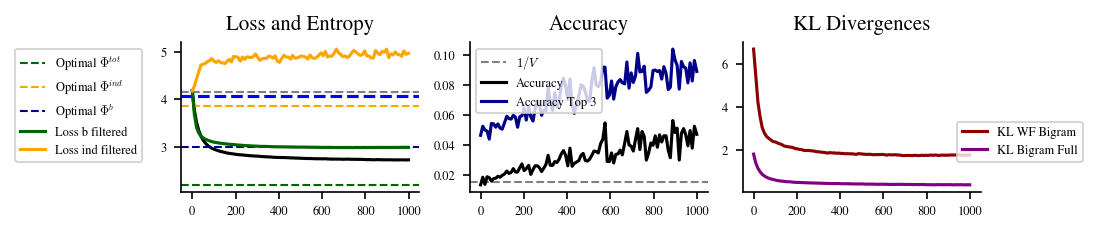

In [5]:
# Settings
set_font_sizes(conf='tight')

# Plot
fig , axes = create_fig(ncols=3,size='double',h=0.2)

ax = axes[0]
# ax.axhline(data['entropy_Pb'], color='red', ls='--')#, label=r'$H(\pi_b)$', lw=1)
ax.axhline(data['entropy_Pu'], color='blue', ls='--')#, label=r'$H(\pi_u)$', lw=1)
ax.axhline(data['max_entropy'], color='gray', ls='--', lw=1)
ax.plot(data['step'],data['loss'],color='black')
ax.axhline(data['opt_loss_dual'], color='darkgreen', ls='--', label=r'Optimal $\Phi^{tot}$', lw=1)
ax.axhline(data['opt_loss_ind'], color='orange', ls='--', label=r'Optimal $\Phi^{ind}$', lw=1)
ax.axhline(data['opt_loss_b'], color='darkblue', ls='--', label=r'Optimal $\Phi^{b}$', lw=1)
# ax.plot(data['step'],data['loss_b_tot'],label='Loss b total',color='darkblue')
# ax.plot(data['step'],data['loss_ind_tot'],label='Loss ind total',color='darkred')
ax.plot(data['step'],data['loss_b_filt'],label='Loss b filtered',color='darkgreen')
ax.plot(data['step'],data['loss_ind_filt'],label='Loss ind filtered',color='orange')
ax.legend(loc=(-0.7,0.2))
ax.set_title('Loss and Entropy')

ax = axes[1]
ax.axhline(1/vocab_size, color='gray', ls='--', label=r'$1/V$', lw=1)
ax.plot(data['step'],data['accuracy'],label='Accuracy',color='black')
ax.plot(data['step'],data['accuracy_top3'],label='Accuracy Top 3',color='darkblue')
ax.legend()
ax.set_title('Accuracy')

ax = axes[2]
ax.plot(data['step'],data['kl_WF_b'],label=r'KL WF Bigram',color='darkred')
# ax.plot(data['step'],data['kl_b_WF'],label=r'KL Bigram WF',color='orange')
# ax.plot(data['step'],data['kl_full_b'],label=r'KL Full Bigram',color='darkblue')
ax.plot(data['step'],data['kl_b_full'],label=r'KL Bigram Full',color='purple')
# ax.plot(data['step'],data['kl_full_u'],label=r'KL Full Unigram',color='darkgreen')
ax.legend(loc=(0.9,0.2))
# ax.set_yscale('log')
ax.set_title('KL Divergences')
# ax.set_xscale('log')


Text(0.5, 1.0, 'KL Divergences')

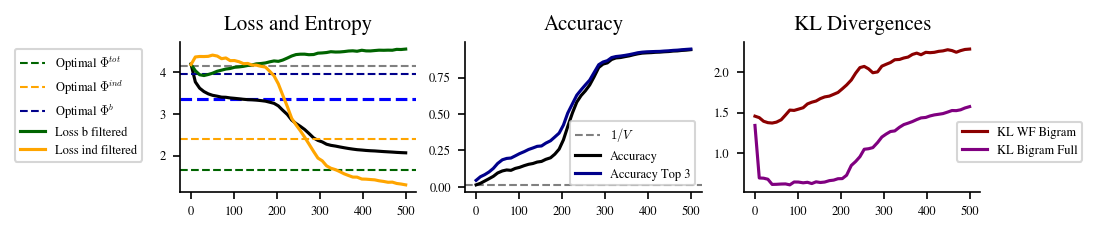

Text(0.5, 1.0, 'KL Divergences')

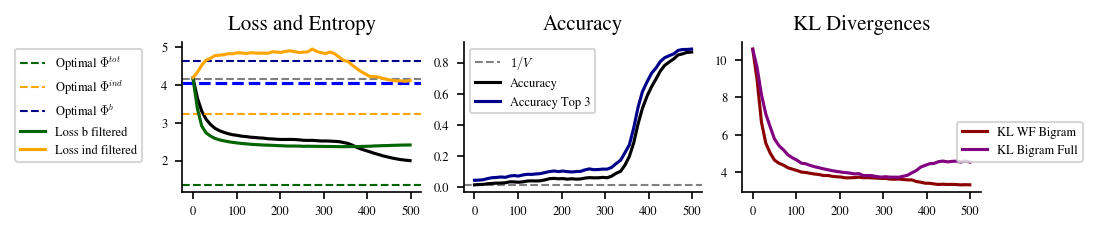

In [168]:
-np.log(0.9)

np.float64(0.10536051565782628)

# Population losses

In [20]:
trig_type = 'rare' # 'freq' or 'rare' or 'rand'
Ks = np.linspace(1,vocab_size-1,num=10,dtype=int)

result = {
    'K': [],
    'phi1': [],
    'phi2': [],
    'phi3': [],
    'trigg_per_seq': [],
}
for K in Ks:
    trigger_set = None
    if fix_trig:
        if trig_type == 'freq':
            trigger_set = [k for k in range(K)]
        elif trig_type == 'rare':
            trigger_set = [vocab_size - 1 - k for k in range(K)] 
        elif trig_type == 'rand':
            trigger_set = torch.multinomial(P_t, num_samples=K, replacement=False).tolist()
        print(f"Using fixed {trig_type} trigger set")
        print(f"Length of trigger set: {len(trigger_set)}, Trigger set: {trigger_set}")
    else:
        print(f"Using random trigger set at each sequence")

    print(f"Evaluating for K={K} trigger tokens...")
    test_batch = generate_dual_task_batch(200,seq_len,K,P_b,P_u,P_o,P_t,trigger_set=trigger_set)
    phi1, phi2, phi3, trigg_per_seq = optimal_pop_losses(test_batch, P_b=P_b, p0=0.99)

    result['K'].append(K)
    result['phi1'].append(phi1)
    result['phi2'].append(phi2)
    result['phi3'].append(phi3)
    result['trigg_per_seq'].append(trigg_per_seq)






Using fixed rare trigger set
Length of trigger set: 1, Trigger set: [63]
Evaluating for K=1 trigger tokens...


Using fixed rare trigger set
Length of trigger set: 7, Trigger set: [63, 62, 61, 60, 59, 58, 57]
Evaluating for K=7 trigger tokens...
Using fixed rare trigger set
Length of trigger set: 14, Trigger set: [63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50]
Evaluating for K=14 trigger tokens...
Using fixed rare trigger set
Length of trigger set: 21, Trigger set: [63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43]
Evaluating for K=21 trigger tokens...
Using fixed rare trigger set
Length of trigger set: 28, Trigger set: [63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36]
Evaluating for K=28 trigger tokens...
Using fixed rare trigger set
Length of trigger set: 35, Trigger set: [63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29]
Evaluating for K=35 trigger tokens...
Using fixed rare trigger set
Length of tri

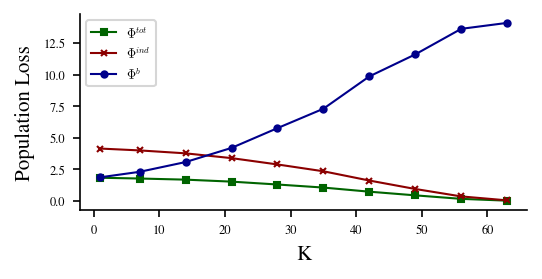

In [23]:
fig , axes = create_fig()
ax = axes

x_var = 'K' # or 'trigg_per_seq'
# x_var = 'trigg_per_seq'

ax.plot(result[x_var], result['phi1'], label=r'$\Phi^{tot}$', color='darkgreen', marker='s', markersize=3, lw=1  )
ax.plot(result[x_var], result['phi2'], label=r'$\Phi^{ind}$', color='darkred', marker='x', markersize=3, lw=1  )
ax.plot(result[x_var], result['phi3'], label=r'$\Phi^{b}$', color='darkblue', marker='o', markersize=3, lw=1  )
ax.set_xlabel(x_var)
ax.set_ylabel('Population Loss')
ax.legend()
plt.show()
